# Customer Segmentation Project

## Thiranex Data Analytics Internship

### Task 2 - Customer Segmentation using K-Means Clustering

## Objective

The objective of this project is to segment customers based on their purchasing behavior using Machine Learning. K-Means Clustering is used to group customers with similar characteristics based on their Annual Income and Spending Score. The insights obtained can help businesses understand customer behavior and create targeted marketing strategies.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "4"   # Un laptop-ku 4 logical cores irundha okay

import warnings

warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first five rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Observation

The dataset has been loaded successfully. It contains customer demographic information such as gender, age, annual income, and spending score, which will be used for customer segmentation.

### Observation

The dataset has been loaded successfully. It contains customer demographic information such as gender, age, annual income, and spending score, which will be used for customer segmentation.

In [3]:
# Display shape of dataset

df.shape

(200, 5)

### Observation

The dataset contains **200 rows** and **5 columns**, providing sufficient customer information for segmentation analysis.

In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Observation

The dataset contains both numerical and categorical features. No incorrect data types were found, making the dataset suitable for further analysis.

In [8]:
# Check missing values

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Observation

No missing values are present in the dataset. Therefore, no imputation or missing value treatment is required.

In [10]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains no duplicate records. This ensures that each customer is represented only once in the analysis.

# Descriptive Statistics

Descriptive statistics summarize the numerical features of the dataset. These statistics help understand customer characteristics such as age, annual income, and spending behavior before performing customer segmentation.

In [11]:
# Summary statistics

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Observation

The descriptive statistics provide an overview of customer demographics and purchasing behavior.

- The average customer age is around 39 years.
- The average annual income is approximately 61k.
- Spending scores range from 1 to 99, indicating customers with both low and high spending habits.

# Customer Gender Distribution

This visualization shows the proportion of male and female customers in the dataset.

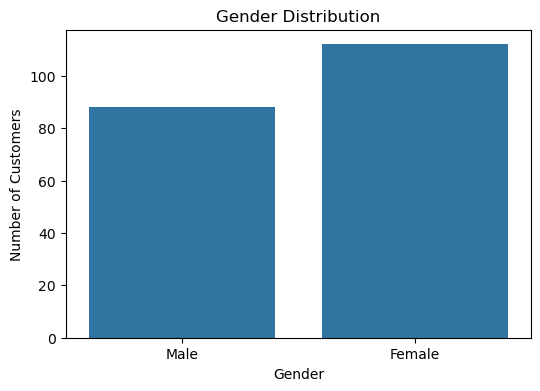

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart shows the gender distribution of customers. This helps determine whether the customer base is balanced or dominated by a particular gender.

# Customer Age Distribution

This histogram illustrates how customer ages are distributed across different age groups.

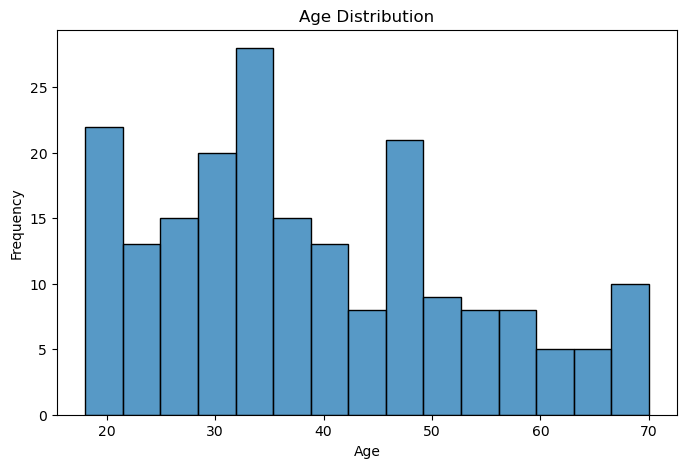

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

Most customers belong to the young and middle-aged groups. Understanding age distribution helps identify the primary target audience.

# Annual Income Distribution

This histogram shows how customers are distributed based on their annual income. It helps identify the income levels of the customer base.

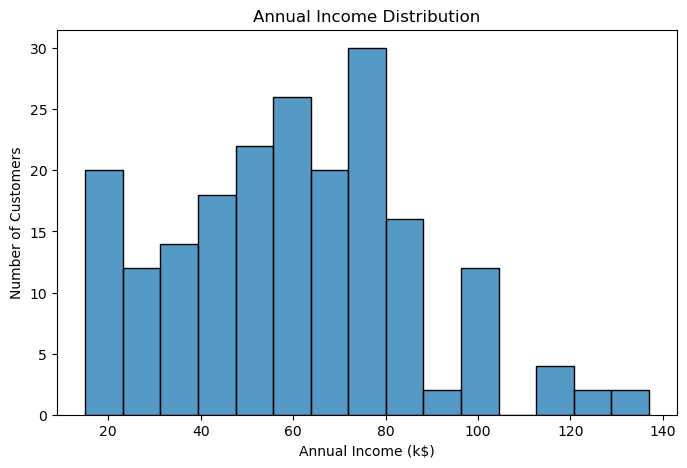

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=15)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The annual income distribution shows that customers belong to different income groups, ranging from low-income to high-income individuals. This information is useful for customer segmentation.

# Spending Score Distribution

This visualization shows the distribution of customer spending scores assigned by the shopping mall.

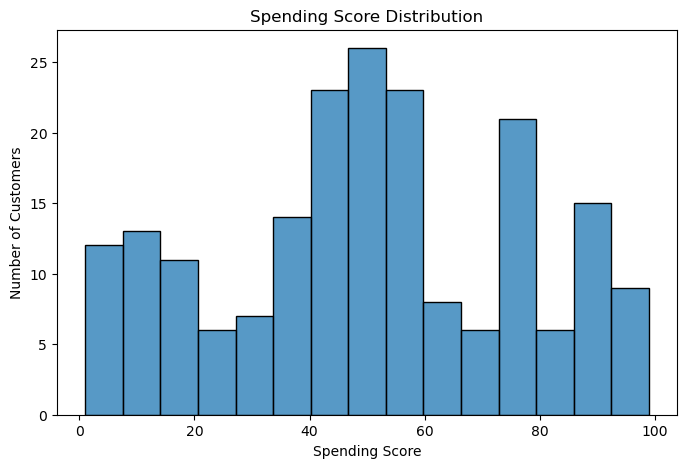

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=15)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The spending scores vary significantly among customers, indicating different purchasing behaviors. Some customers spend very little, while others are frequent high spenders.

# Correlation Analysis

A correlation heatmap is used to examine the relationships between numerical variables in the dataset.

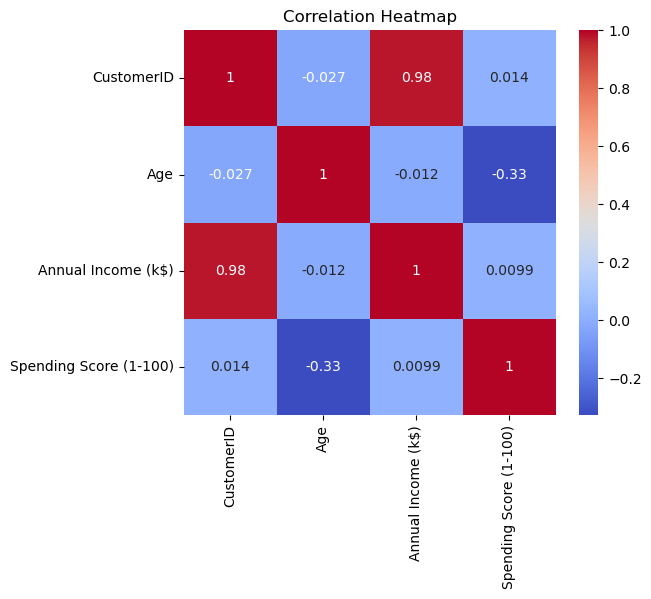

In [8]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the correlation between numerical variables. Most variables have weak correlations, indicating that age, income, and spending score are relatively independent of one another.

# Feature Selection for Clustering

Customer segmentation will be performed using Annual Income and Spending Score, as these two variables best represent customer purchasing behavior.

In [9]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K) for K-Means clustering. The point where the curve bends like an elbow is considered the ideal number of clusters.

In [15]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

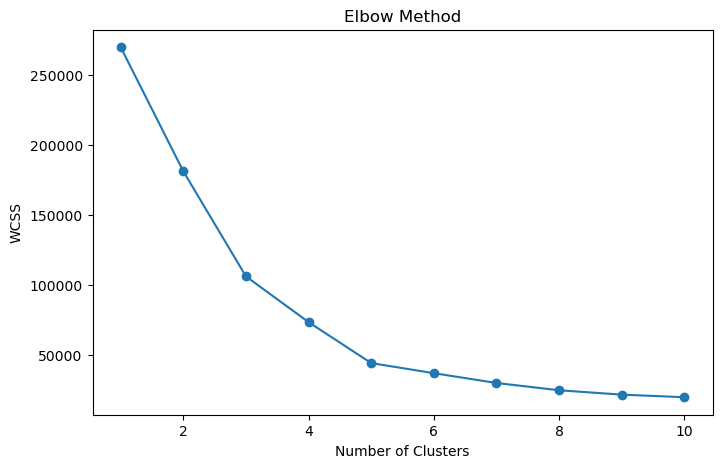

In [11]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

### Observation

The Elbow Method helps determine the optimal number of clusters. The point where the curve bends significantly indicates the ideal value of K. For this dataset, the elbow is typically observed around **5 clusters**.

# K-Means Clustering

Using the optimal number of clusters obtained from the Elbow Method, K-Means is applied to segment customers into different groups.

In [16]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# Customer Segmentation Visualization

This scatter plot visualizes the customer segments generated using the K-Means clustering algorithm. Each color represents a different customer group based on Annual Income and Spending Score.

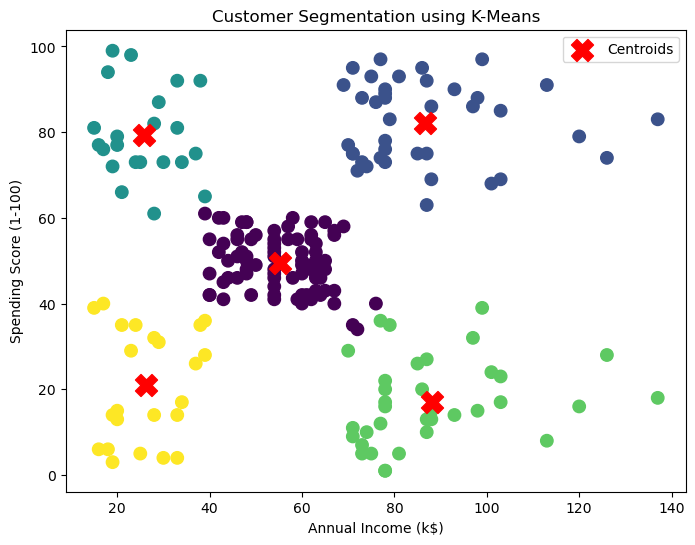

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

### Observation

The scatter plot shows five distinct customer segments based on Annual Income and Spending Score. Customers within the same cluster exhibit similar purchasing behavior, while different clusters represent unique customer groups. The red "X" markers indicate the cluster centroids.

# Cluster Analysis

This section shows the number of customers present in each cluster.

In [19]:
df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Observation

The output displays the number of customers assigned to each cluster. This helps understand the distribution of customers across different segments.

# Business Insights

- Customers with **high income and high spending score** are premium customers and should be retained through loyalty programs.
- Customers with **high income but low spending score** can be targeted with personalized offers and promotions.
- Customers with **low income but high spending score** may respond well to discounts and seasonal campaigns.
- Customers with **low income and low spending score** require cost-effective marketing strategies.
- Customer segmentation enables businesses to create targeted marketing campaigns, improve customer satisfaction, and increase overall revenue.

# Conclusion

This project successfully segmented customers into meaningful groups using the K-Means clustering algorithm. The analysis identified different customer behaviors based on Annual Income and Spending Score. These customer segments can help businesses design personalized marketing strategies, improve customer engagement, and make data-driven decisions.